# Task 3 Table Retrieval

# 1. Feature Extraction & Content-Based Image Retrieval (CBIR)

Instead of matching raw pixels, you extract high-level features from the query image and compare them against your training data.

 - Global Image Embeddings: Pass the image through a pre-trained Deep Neural Network (like ResNet, ViT, or CLIP) to get a dense vector embedding representing the whole scene.

 - Metric Learning (Triplet Loss / Contrastive Learning): Train a network so that similar pool table configurations end up close together in the vector space, while drastically different setups are pushed far apart.

 - Vector Similarity Search: Use libraries like FAISS (Facebook AI Similarity Search) or Chroma to instantly retrieve the top-k nearest neighbors (most similar tables) using cosine similarity or Euclidean distance.

# 2. Object Detection & Spatial Graph Matching

Since a pool table's state is defined entirely by its boundaries and the coordinates of the balls, explicit geometric techniques work incredibly well here.

- Ball and Pocket Detection: Use an object detection model (like YOLOv8 or Faster R-CNN) to detect the precise bounding boxes of the balls, cue ball, and pockets (as seen outlined in your image).

- Homography Estimation (2D Projection): Detect the corners of the pool table to compute a homography matrix. Transform the skewed 3D camera perspective into a bird's-eye view (2D top-down grid).

- Graph Neural Networks (GNNs): Represent the table as a graph where nodes are balls (with color/type attributes) and edges represent the relative distance and angles between them. Table retrieval then becomes a Graph Matching problem.

In [1]:
%pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 79.4 MB/s eta 0:00:00


In [1]:
import torch
from torchvision.transforms import v2 as transforms
from torch.nn import functional as F
import torchvision
import matplotlib.pyplot as plt
import os, random, re
import pandas as pd
import numpy as np
from PIL import Image

In [3]:
from google.colab import drive
import os
import zipfile

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
import zipfile
from pathlib import Path

zip_file_path = "/content/drive/MyDrive/data/yolo_dataset.zip"

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(".")
    print(f"Successfully extracted all files")

except FileNotFoundError:
    print(f"Error: The file '{zip_file_path}' was not found.")
except zipfile.BadZipFile:
    print("Error: The file is corrupted or not a valid zip archive.")

Successfully extracted all files


In [5]:
from ultralytics import YOLO

# 1. Initialize a new YOLOv8 nano model (or use 'yolov8s.pt' / 'yolov8m.pt' for larger models)
device = 'cuda'
model = YOLO("yolov8n.pt")

# 2. Train the model
results = model.train(
    data="./yolo_dataset/data.yaml",  # Path to the generated configuration file
    epochs=50,                        # Adjust based on how long you want to train
    imgsz=640,                        # Standard YOLO resolution
    device=device                          # Set to 0 if you have a GPU available, or "cpu"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64

In [9]:
import shutil
import os

# shutil.copy('/content/runs/detect/train/weights/best.pt', '/content/drive/MyDrive/data/pool_yolo_best.pt')
os.system("zip -r yolo_training_run.zip runs/detect/train")
shutil.copy('/content/yolo_training_run.zip', '/content/drive/MyDrive/data/yolo_training_run.zip')

'/content/drive/MyDrive/data/yolo_training_run.zip'


image 1/1 /home/ricardo/dev/CV_PROJECT_1/images/0_png.rf.e35063c144cfd241454863d624cf01d3.jpg: 384x640 1 Dot, 3 Solids, 2 Stripeds, 40.6ms
Speed: 1.9ms preprocess, 40.6ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)
--- Detections ---
Detected [Striped] with 65.43% confidence at [803, 473, 819, 486]
Detected [Solid] with 48.64% confidence at [755, 463, 774, 481]
Detected [Solid] with 45.85% confidence at [754, 455, 772, 476]
Detected [Striped] with 43.33% confidence at [1060, 520, 1078, 539]


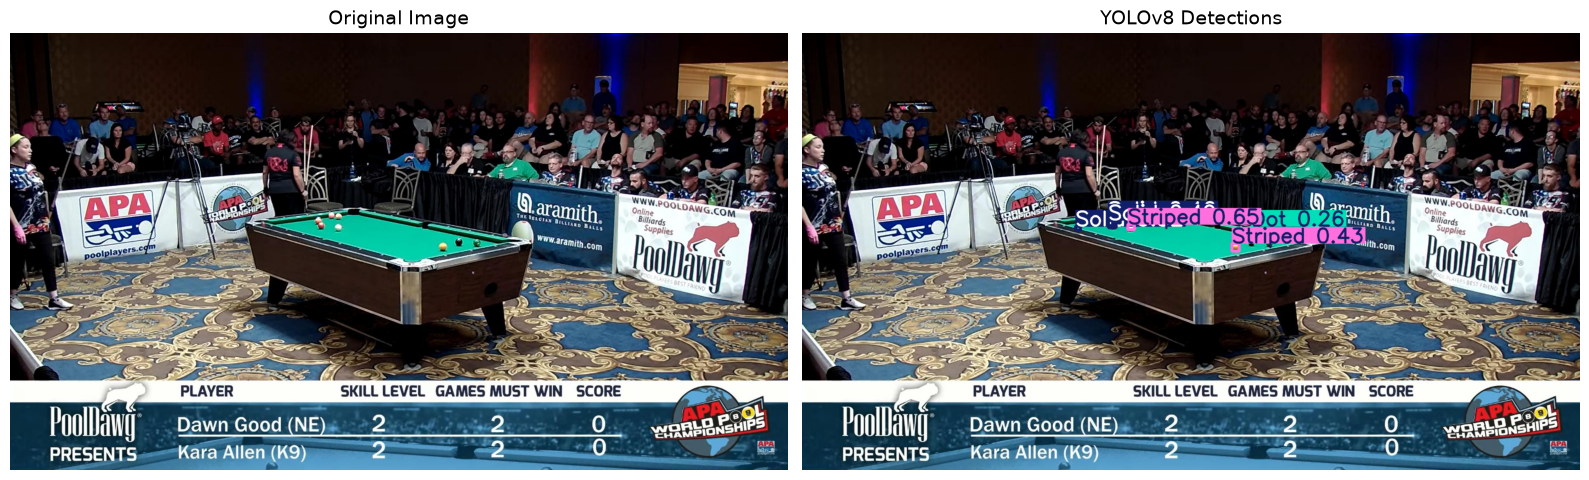

In [5]:
import cv2
from ultralytics import YOLO

# 1. Load your custom trained model
# Replace 'best.pt' with the actual path to your file if it's in another folder
model = YOLO("pool_yolo_best.pt")

# 2. Run inference on a local pool table image
# (Make sure this image path exists on your PC)
image_path = "images/0_png.rf.e35063c144cfd241454863d624cf01d3.jpg"
results = model(image_path, device='cpu')

print("--- Detections ---")
for result in results:
    boxes = result.boxes
    for box in boxes:
        # Get class ID and text name
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        confidence = float(box.conf[0])
        
        # Coordinates: [x_min, y_min, x_max, y_max]
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        
        if confidence > 0.4:
            # Fixed formatting bug here:
            print(f"Detected [{class_name}] with {confidence:.2%} confidence at [{x1}, {y1}, {x2}, {y2}]")

# 3. Prepare the images for Matplotlib display
# Load original image and convert from BGR to RGB
orig_img = cv2.imread(image_path)
orig_img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

# Get the annotated image from YOLO and convert from BGR to RGB
annotated_img = results[0].plot()
annotated_img_rgb = annotated_img[:, :, ::-1]

# 4. Plot Side-by-Side using Matplotlib
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left Plot: Original
axes[0].imshow(orig_img_rgb)
axes[0].set_title("Original Image", fontsize=14)
axes[0].axis("off")

# Right Plot: YOLO Detections
axes[1].imshow(annotated_img_rgb)
axes[1].set_title("YOLOv8 Detections", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Homography

Too  much work do this way again for the green velt pool table... but should be possible.